# Visual Place Cell Clustering

This notebook takes the raw observation dataset collected during data collection and produces a trained **Visual Place Cell (VPC) ensemble** by clustering the multimodal feature vectors. The resulting ensemble (cluster centers + radii) is saved to disk and used at runtime to compute place cell activations.

---

## Pipeline Overview

```
Data Collection Controller
        ↓
data/vpce/habituation/<maze>.h5     ← raw observations (feature vectors + poses)
        ↓
    Clustering on full dataset  (this notebook)
        ↓
data/vpce/place_cells/<maze>.h5     ← trained VPC ensemble (centers + radii)
        ↓
    Activation projection onto x,y plane  (this notebook)
```

The train/test split for evaluation is handled downstream in the analysis pipeline — see the evaluation notebook.

## Habituation Dataset Structure

The habituation dataset is stored as an HDF5 file with one dataset per field:

| Dataset | Shape | Description |
|---|---|---|
| `multimodal_features` | `(N, feature_dim)` | Feature vector for a single POV image |
| `x` | `(N,)` | Robot x coordinate at time of observation |
| `y` | `(N,)` | Robot y coordinate at time of observation |
| `theta` | `(N,)` | Heading (radians) the POV image was captured at |
| `landmark_mask` | `(N, n_landmarks)` | Which landmarks are visible from this POV |
| `landmark_azimuths` | `(N, n_landmarks)` | Egocentric bearing (radians) to each landmark, NaN if not visible |

Each row `i` corresponds to a single POV image captured at one of 8 evenly spaced
headings (0°, 45°, 90°, ..., 315°) at a given `(x, y)` location — 8 consecutive
rows per location, in heading order.

`combine_pov_observations(dataset, N_COMBINE)` groups these rows back by location
and combines `N_COMBINE` adjacent headings (a centered, circular window) into each
output datapoint:

- `N_COMBINE = 1` — each heading is its own datapoint (no combination)
- `N_COMBINE = 3` — each heading combined with its left/right neighbors
- `N_COMBINE = n_orientations` (8) — all headings at a location collapsed into one
  datapoint (`theta` and `landmark_azimuths` are `NaN`, since no single heading applies)


## Clustering Algorithms

Clustering maps the high-dimensional feature vectors into a set of **place cell centers** (cluster centroids) and **radii** (receptive field width of each cluster). Two methods are available in `realm_tools.place_cell_lib.clustering`:

### K-Means
Partitions the feature space into `k` clusters by minimizing within-cluster variance. Each cluster centroid becomes a place cell center.

- **Pros:** Fast, deterministic (with fixed seed), scales well to large datasets.
- **Cons:** Assumes spherical clusters of equal size; single field per cell.

### Gaussian Mixture Model (GMM)
Models the feature distribution as a weighted sum of `k` Gaussians. Each Gaussian component becomes a place cell. Hard cluster assignments are obtained via `predict` for radius estimation.

- **Pros:** Soft cluster assignments during fitting; can capture elliptical structure.
- **Cons:** More expensive to fit; sensitive to initialisation.

Both functions share the same interface:
```python
centers, radii = fit_kmeans(features, n_clusters)
centers, radii = fit_gmm(features, n_components)
```

### Radius Definition

The radius $\sigma_i$ for each place cell is the **maximum Euclidean distance** from any member of that cluster to its centroid:

$$\sigma_i = \max_{j \in C_i} \|\mathbf{f}_j - \mathbf{c}_i\|$$

This keeps $\sigma$ in the same units as the total feature-space Euclidean distance, ensuring the RBF exponent is correctly scaled regardless of feature dimensionality. Using a per-dimension variance statistic (e.g. mean diagonal covariance) would underestimate $\sigma$ by a factor of $\sqrt{D}$, driving all activations to zero.

## Place Cell Activation Model

Once the ensemble is trained, each **Visual Place Cell** computes its activation via a **Radial Basis Function (RBF)** over the distance between a new observation's feature vector and the cell's stored centroid:

$$a_i = \exp\left(-\frac{\|\mathbf{f} - \mathbf{c}_i\|^2}{2\sigma_i^2}\right)$$

where:
- $\mathbf{f}$ is the feature vector of the current observation  
- $\mathbf{c}_i$ is the centroid of place cell $i$  
- $\sigma_i$ is the radius (receptive field width) of place cell $i$  

Activations are then **normalized** across the population so they sum to 1, producing a population vector that encodes the current location as a graded pattern of activity.

## Place Cell Ensemble — Saved Model Structure

The trained ensemble is stored as an HDF5 file under `data/vpce/place_cells/`:

| Dataset / Attribute | Type | Description |
|---|---|---|
| `centers` | `(N_cells, feature_dim)` | Cluster centroids in feature space |
| `radii` | `(N_cells,)` | RBF sigma per cell |
| `attrs['method']` | `str` | Clustering algorithm used (`'kmeans'` or `'gmm'`) |
| `attrs['maze']` | `str` | Maze the model was trained on (e.g. `'LM8'`) |
| `attrs['n_cells']` | `int` | Number of place cells |

---
## Configuration

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # set working directory to project root

import numpy as np
import matplotlib.pyplot as plt

from realm_tools.experiment_lib.loggers import PovDataset, PlaceCellEnsemble, combine_pov_observations
from realm_tools.place_cell_lib import fit_kmeans, fit_gmm, VisualPlaceCellEnsemble

In [5]:
MAZE      = 'lm8'   # lm8 | lm8_r45 | lm8_r90 | lmo8
N_COMBINE = 1       # number of adjacent headings (centered, circular) to
                    # average into one datapoint: 1, 3, 5, ... or 8 (collapse
                    # all headings at a location into a single datapoint)
METHOD    = 'kmeans'   # 'kmeans' | 'gmm'
N_CELLS   = 750
REG_COVAR = 1e-3    # GMM covariance regularisation — increase (e.g. 1e-2) if
                    # you get ill-defined covariance errors on large datasets

N_SAMPLE_CELLS = 10  # number of place cells to show in the per-heading
                     # orientation grid below; set to None to show all K cells

DATA_PATH   = f'data/vpce/collect_data/{MAZE}'
OUTPUT_PATH = f'data/vpce/place_cells/{MAZE}'
MAZE_XML    = f'simulation/worlds/environments/vpce/{MAZE}.xml'

---
## Load Habituation Dataset

In [3]:
dataset  = PovDataset.load_dataset(DATA_PATH)
combined = combine_pov_observations(dataset, N_COMBINE)

features = np.array(combined['multimodal_features'])
poses    = np.stack([combined['x'], combined['y'], combined['theta']], axis=1)

print(f"Observations : {features.shape[0]}")
print(f"Feature dim  : {features.shape[1]}")
print(f"Pose shape   : {poses.shape}")


Observations : 52000
Feature dim  : 7364
Pose shape   : (52000, 3)


In [6]:
if METHOD == 'kmeans':
    centers, radii = fit_kmeans(features, n_clusters=N_CELLS)
elif METHOD == 'gmm':
    centers, radii = fit_gmm(features, n_components=N_CELLS, reg_covar=REG_COVAR)
else:
    raise ValueError(f"Unknown method: {METHOD}")

print(f"Method    : {METHOD}")
print(f"Cells     : {len(centers)}")
print(f"reg_covar : {REG_COVAR}")
print(f"Radii     — min: {radii.min():.4f}  max: {radii.max():.4f}  mean: {radii.mean():.4f}")

Method    : kmeans
Cells     : 750
reg_covar : 0.001
Radii     — min: 841.7570  max: 2795.2583  mean: 1539.0981


---
## Inspect Radii Distribution

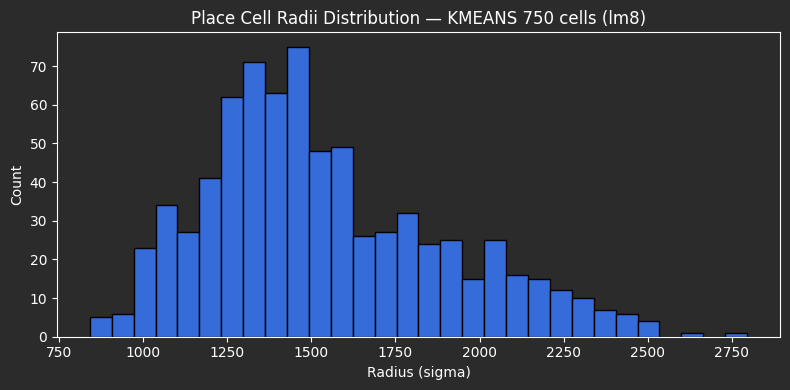

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(radii, bins=30, edgecolor='black')
ax.set_xlabel('Radius (sigma)')
ax.set_ylabel('Count')
ax.set_title(f'Place Cell Radii Distribution — {METHOD.upper()} {N_CELLS} cells ({MAZE})')
plt.tight_layout()
plt.show()

---
## Save Place Cell Ensemble

In [8]:
ensemble         = PlaceCellEnsemble()
ensemble.centers = centers
ensemble.radii   = radii
ensemble.save(OUTPUT_PATH, method=METHOD, maze=MAZE)

Place cell ensemble saved to data/vpce/place_cells/lm8.h5  (750 cells)


---
## Place Cell Activation Projection

For each place cell, the RBF activation is computed at every observed position and projected onto the x,y plane as a heat map superimposed on the maze boundary.

Each subplot shows one place cell. Warm colours (yellow/white) indicate high activation — the region of the maze where that cell fires most strongly. Cool colours (dark) indicate low activation.

The activation for cell $i$ at observation $\mathbf{f}$ is:

$$a_i = \exp\!\left(-\frac{\|\mathbf{f} - \mathbf{c}_i\|^2}{2\,\sigma_i^2}\right)$$

where $\sigma_i$ is the **max Euclidean distance** from any cluster member to its centroid — the same scale as the Euclidean distance used in the numerator. A point at the cluster boundary activates at $e^{-0.5} \approx 0.61$; points outside the boundary decay smoothly to zero.

The activation matrix is computed memory-efficiently using:

$$\|\mathbf{f} - \mathbf{c}_i\|^2 = \|\mathbf{f}\|^2 - 2\mathbf{f}\cdot\mathbf{c}_i^T + \|\mathbf{c}_i\|^2$$

avoiding the naive `(N, K, D)` expansion.

In [13]:
from realm_tools.image_lib.analysis_plots import plot_place_cell_activations

ensemble    = VisualPlaceCellEnsemble(centers, radii)
activations = ensemble.activate(features)
print(f"Activation matrix: {activations.shape}")

plot_place_cell_activations(
    activations = activations,
    poses       = poses,
    maze_xml    = MAZE_XML,
    maze        = MAZE,
    method      = METHOD,
    save        = True,
)

KeyboardInterrupt: 

---
## Activation Projection — Base Figure Overlay

Same activation heatmaps as above, but superimposed on the real base figure image of the maze. The heatmap is blended using **per-pixel alpha** — each pixel's opacity equals its normalised activation value. Low-activation regions are fully transparent (showing the base photo); high-activation regions are fully opaque (inferno colours on top).

`BASE_EXTENT` maps the image pixel space to world coordinates (metres). Adjust it to match the crop of your base figure — the default assumes the `make_environment_plot` output which spans ±4.25 m.

In [ ]:
from realm_tools.image_lib.analysis_plots import plot_place_cell_activations_overlay

plot_place_cell_activations_overlay(
    activations   = activations,
    poses         = poses,
    maze_xml      = MAZE_XML,
    base_img_path = f'analysis/base_figures/{MAZE}.png',
    maze          = MAZE,
    method        = METHOD,
    flip_base_img = True,
    save          = True,
)

---
## Activation by Heading

The plots above project each cell's activation onto the x,y plane. When
`N_COMBINE < 8`, each location has multiple datapoints — one per heading — so a
single x,y heatmap (or quiver field) can be hard to read cell-by-cell.

This grid shows one row per place cell and one column per heading, so you can
compare how a cell's spatial activation pattern shifts with orientation. Set
`N_SAMPLE_CELLS` above to a small number (e.g. 10) to randomly sample cells, or
`None` to show all K cells (large for big K). If `N_COMBINE == 8`, there's only
one combined datapoint per location, so each cell gets a single column.


Activation matrix: (52000, 750)
Saved  →  analysis/figures/place_cell_activity_plots/lm8_kmeans_orientation_activations_n10.png


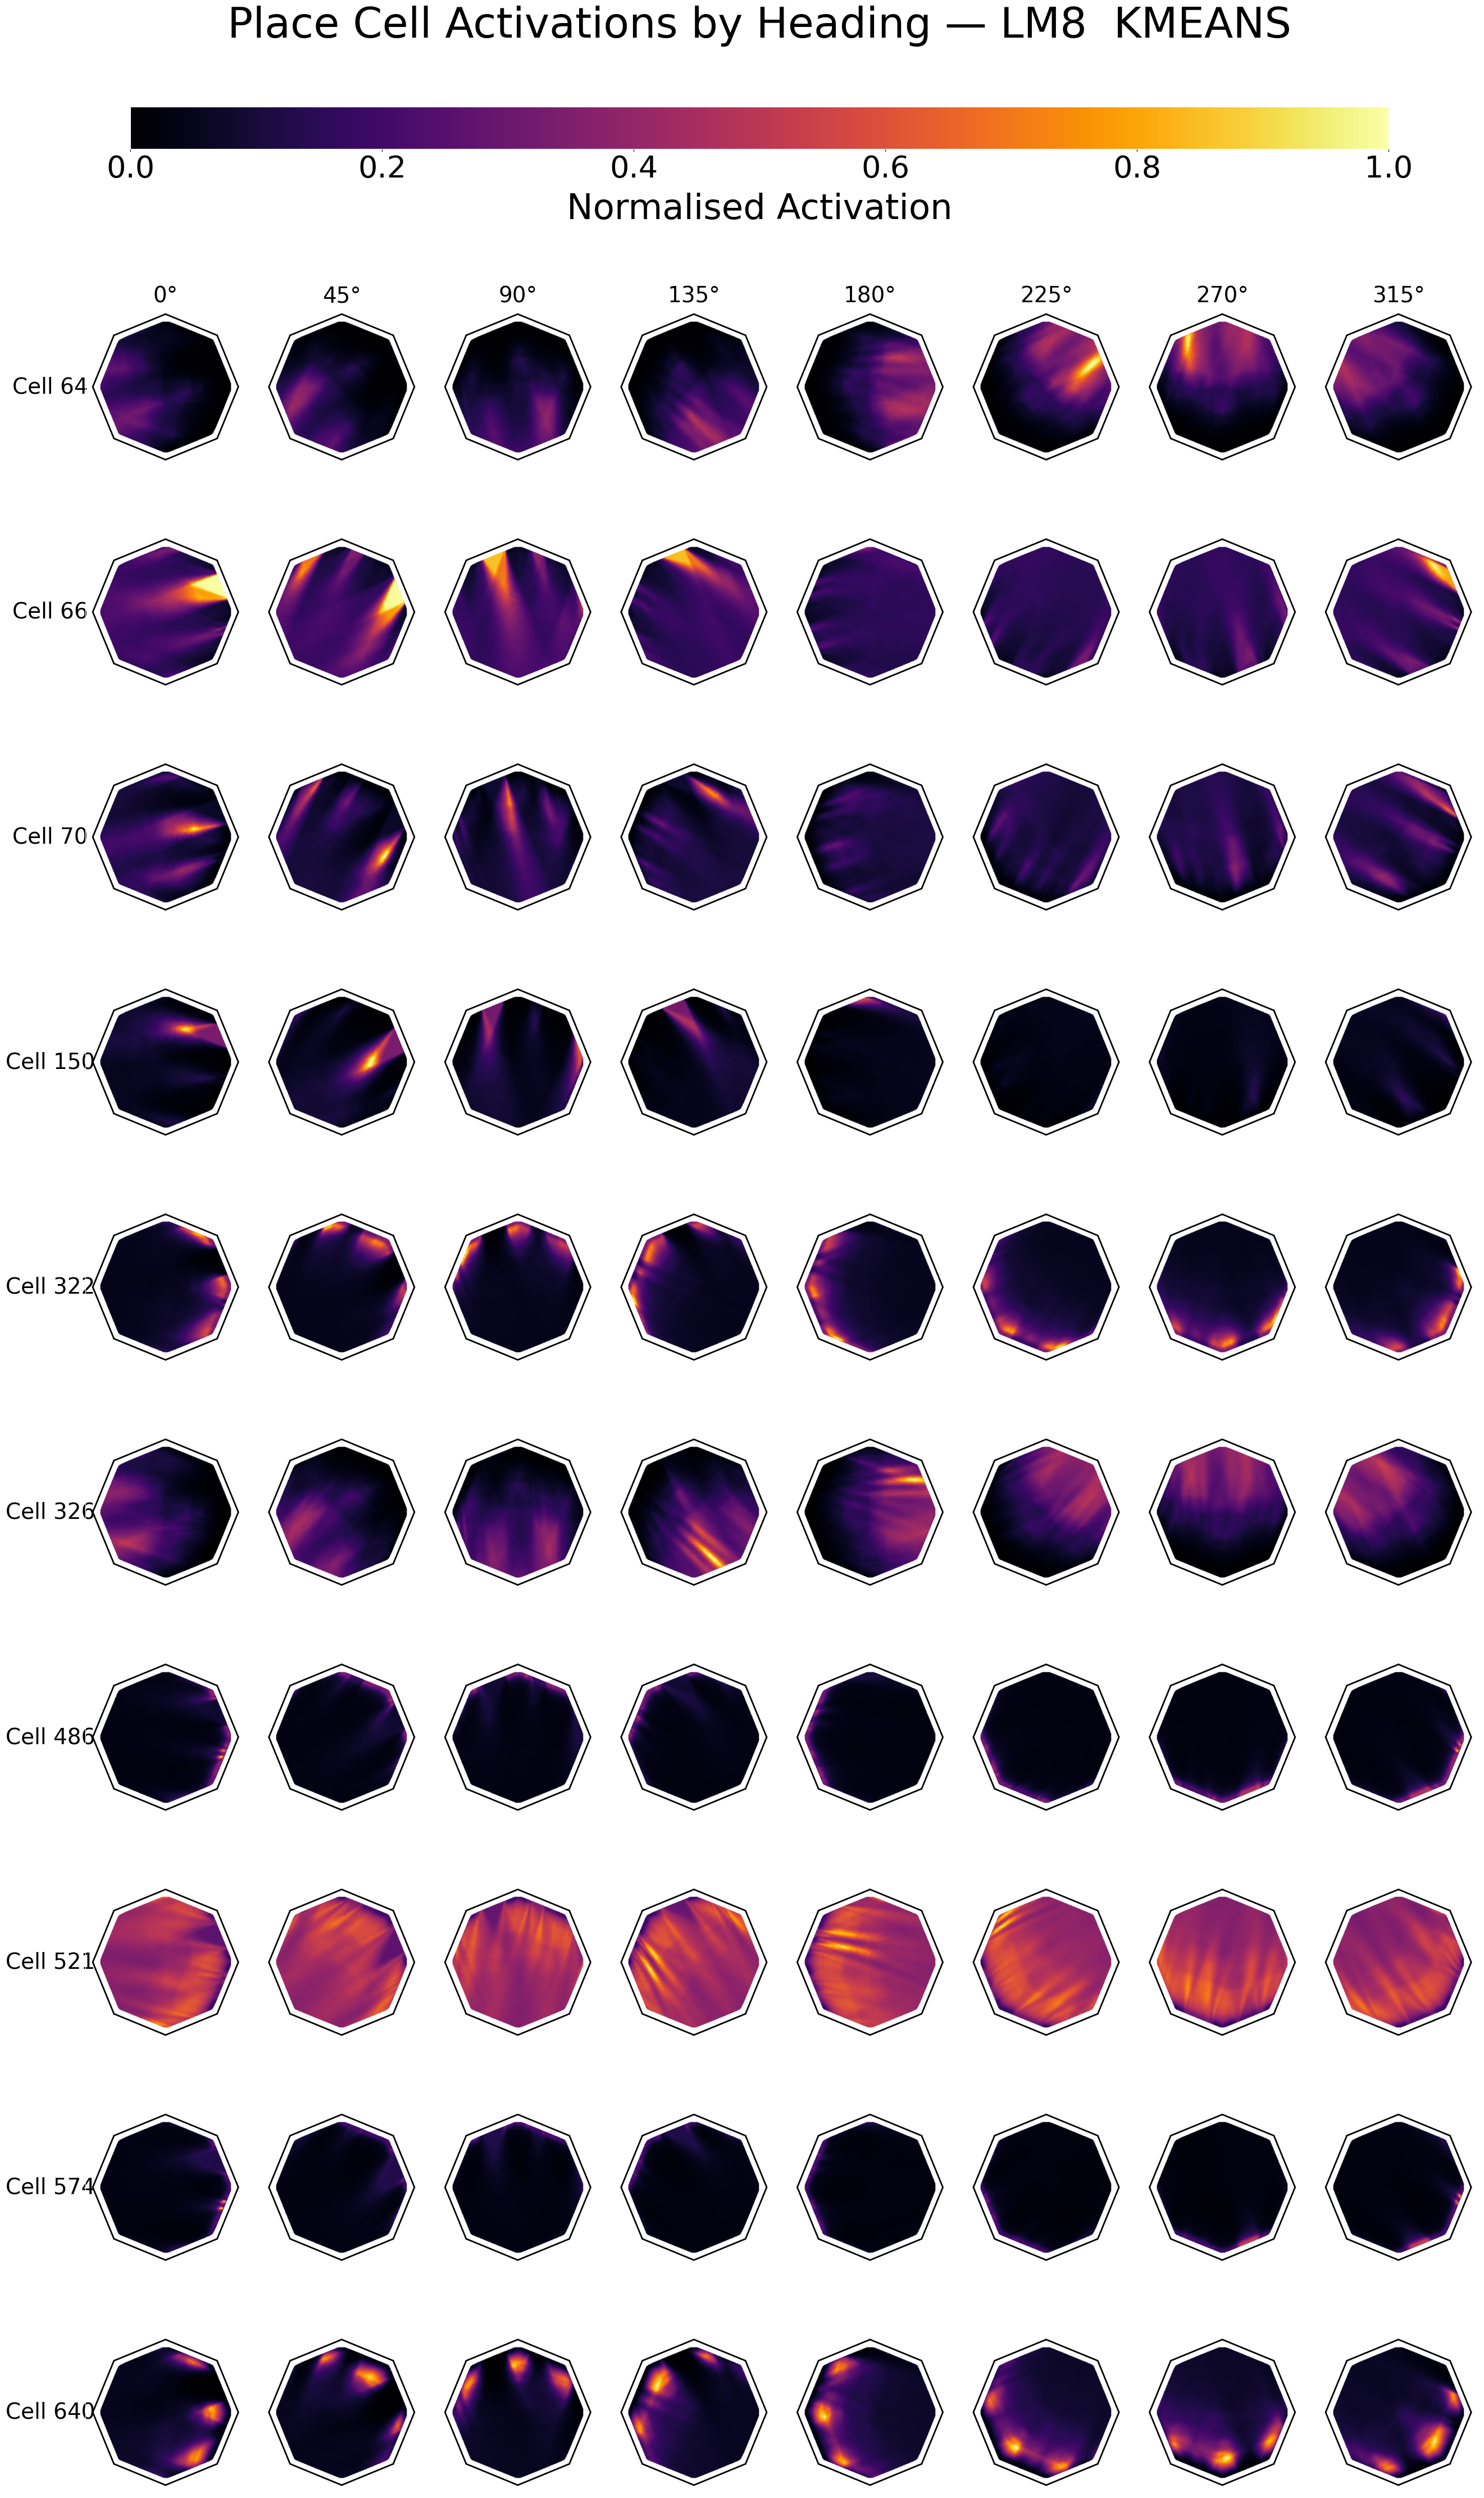

In [10]:
from realm_tools.image_lib.analysis_plots import plot_place_cell_orientation_activations

plot_place_cell_orientation_activations(
    activations    = activations,
    poses          = poses,
    maze_xml       = MAZE_XML,
    maze           = MAZE,
    method         = METHOD,
    n_sample_cells = N_SAMPLE_CELLS,
    save           = True,
)
